# Homework 10

## By: Mohammad Zoraiz

## Pytorch
In this exercise, you will practice using deep learning with artificial neural networks and the Pytorch library to build classification models. Note that Pytorch is **not** installed by default and must be installed separately. You have three options for using Pytorch to complete this assignment:

1. Install Pytorch locally (for free). You can see the directions on the [Pytorch website here](https://pytorch.org/get-started/locally/). Select the stable build, your operating system, Pip, Python, and CPU to see install directions for your particular setup. (CUDA is used to support hardware acceleration with NVIDIA graphics cards and is not necessary for this course).

1. Use a [Duke OIT container](https://cmgr.oit.duke.edu/containers). Make sure to use the **PyTorch** one. If you have not already reserved your container, see the class website's [Resources & Getting Help](https://sites.duke.edu/compsci216sp2026/resources/) page.

1. Use Pytorch in a Jupyter notebook in the cloud (also for free). The easiest way to do this is with a Google colab notebook; Pytorch will already be available to you in this cloud environment. If you choose this option, go to the [Google colab website](https://colab.research.google.com) select "Upload" at the right side of the orange menu bar, and select this `.ipynb` file. You can then complete the assignment in colab and download the completed `.ipynb` file to turn in on Gradescope.

## About this homework
The code in this assignment is based on the image classification example presented in the [Deep Learning with Pytorch: A 60 Minute Blitz](https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html) tutorial and the [Pytorch Basics Tutorial](https://pytorch.org/tutorials/beginner/basics/intro.html#). You are welcome and encouraged to visit these and other Pytorch [tutorials](https://pytorch.org/tutorials/), [documentation](https://pytorch.org/docs/stable/index.html), and [recipes/examples](https://pytorch.org/tutorials/recipes/recipes_index.html) as needed or for your own interest and learning.

## Grading for this homework
This assignment is tutorial style; in general, we will provide the necessary code and simply ask you to run the code, observe what happens, and answer questions based on the code. There are two parts:
1. **Canvas Quiz** - Some of the questions you will answer as a Canvas Quiz (with unlimited attempts).
1. **Markdown write ups** - The rest of the questions you will answer in this notebook.

**Strong Recommendation**: Restart and run all the cells of this notebook once when you start this homework. After running it do not run it again. Instead, only update the markdown cells with your answers. Running markdown cells multiple times to render them does not change the code cell counts. When you finish, please confirm that your notebook and its output look correct before submitting your `.ipynb` file (the notebook file) on Gradescope. If you follow this recommendation, you should not need to restart and run all again, but if you do, please allow time for the code to finish executing; the code in this notebook takes time to run!

**If you are encountering errors** while running the code and already have PyTorch installed, it is possible that the version you have is outdated. PyTorch regularly releases new versions, and using an outdated version may cause compatibility issues with the code. You can use `pip install torch torchvision --upgrade` command in your terminal to upgrade.

### Question 1: The Data
First, we import the necessary libraries and download the `CIFAR-10` dataset from Pytorch. The `CIFAR-10` dataset consists of 60,000 32 by 32 pixel color images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images. The classes of the images are things like `airplane`, `automobile`, `bird`, `cat`, `deer`, etc. You can read more about the dataset at the [curator's website](https://www.cs.toronto.edu/~kriz/cifar.html). 

Run the following code to import necessary libraries, download the data, and preview some of the images along with their classes. **Note that this step may take a few minutes depending on your internet speed**; the dataset is about 160 MB. Once you have downloaded the data once, rerunning the cell should be fast; it will verify that you already have the dataset rather than redownload every time.

In [1]:
# Run but do not modify this code
# Imports all of the necessary Pytorch libraries

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim

In [2]:
# Run but do not modify this code
# Downloads, imports, and formats the CIFAR-10 image dataset. 
# May take a few minutes the first time you run it

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
train_dataloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
test_dataloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

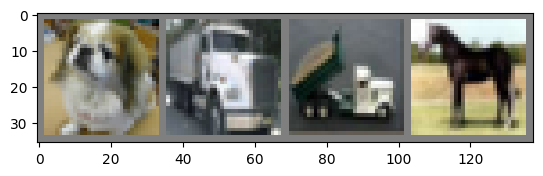

  dog truck truck horse


In [3]:
# Run but do not modify this code
# Displays random images from the CIFAR-10 image dataset

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(train_dataloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))
plt.show()

After running this code, `images` is a tensor containing the images displayed above. Run the code below to see the shape of the tensor, which is 4 by 3 by 32 by 32. Explain these values: What do these numbers represent in terms of the data?

In [4]:
# Run but do not modify this code
print(images.shape)

torch.Size([4, 3, 32, 32])


**Please write your answer for question 1 here**

### Answer 1

The shape `torch.Size([4, 3, 32, 32])` breaks down as:

- **4** — batch size; we loaded 4 images at once (`batch_size=4` in the DataLoader)
- **3** — color channels: Red, Green, Blue
- **32** — image height in pixels
- **32** — image width in pixels

So each image is a 32×32 RGB image, and the tensor holds a batch of 4 of them stacked together.

<!-- END QUESTION -->

### Question 2
Now we will start by defining a (relatively) small multilayer perceptron for classifying these images.

In [5]:
# Run but do not modify this code
# Defines a multilayer perceptron class

class MultilayerPerceptron(nn.Module):
    def __init__(self):
        super(MultilayerPerceptron, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(32*32*3, 100),
            nn.ReLU(),
            nn.Linear(100, 25),
            nn.ReLU(),
            nn.Linear(25, 10),
            nn.ReLU()
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

Answer the following questions about this `MultilayerPerceptron` defined in the code above.
1. How many inputs are there in the input layer of the neural network?
2. How many **hidden** (that is, apart from the input and output layers) fully connected linear layers are there in the network?
3. What nonlinear activation function is the network using?
4. How many parameters are there for the connection between the input layer and the first hidden fully connected layer in the network?

**Please fill your answers to question2 on Canvas**


In [6]:
# You can use this cell to play around and use as calculator
# but you should fill them on Canvas quiz once you have the values

...

Ellipsis

### Question 3
Now we define our hyperparameters, initialize our model and optimizer, and define our training and testing process. The training uses stochastic gradient descent and prints the average training loss after every 1,250 batches or 5,000 images. After each of three epochs of training we print the average accuracy of the model on the held out test data; this is the percentage of the test images that our model correctly classifies.

In [7]:
# Run but do not modify this code
# Defines hyperparameters 

torch.manual_seed(216)
learning_rate = 1e-3
epochs = 3

In [8]:
# Run but do not modify this code
# Initializes the network, loss function, and optimizer

model = MultilayerPerceptron()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [9]:
# Run but do not modify this code
# Defines the training optimization process and
# calculating accuracy on the held out testing data

def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    avg_batch_loss = 0.0
    for batch, (X, y) in enumerate(dataloader):
        
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        avg_batch_loss += loss.item()

        # Print average loss every 1250 batches
        if ((batch > 0) and (batch % 1250 == 0)):
            loss, current = loss.item(), batch * len(X)
            print(f"Average Loss: {avg_batch_loss/1250:>7f}  [{current:>5d}/{size:>5d}]")
            avg_batch_loss = 0.0
            
def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= size
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [10]:
# Run but do not modify this code
# Performs 'epochs' of training with stochastic
# gradient descent, printing average loss of every
# 1250 batches. Prints test accuracy after each
# epoch.
# NOTE: Optimization on 50,000 training samples may take
# some time, expect this code to run for several seconds 
# to a couple of minutes.

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
Average Loss: 2.290818  [ 5000/50000]
Average Loss: 2.275833  [10000/50000]
Average Loss: 2.257851  [15000/50000]
Average Loss: 2.230425  [20000/50000]
Average Loss: 2.215106  [25000/50000]
Average Loss: 2.187408  [30000/50000]
Average Loss: 2.172581  [35000/50000]
Average Loss: 2.161809  [40000/50000]
Average Loss: 2.122550  [45000/50000]
Test Error: 
 Accuracy: 28.2%, Avg loss: 0.524443 

Epoch 2
-------------------------------
Average Loss: 2.087561  [ 5000/50000]
Average Loss: 2.074460  [10000/50000]
Average Loss: 2.063034  [15000/50000]
Average Loss: 2.048042  [20000/50000]
Average Loss: 2.048554  [25000/50000]
Average Loss: 2.032419  [30000/50000]
Average Loss: 2.012721  [35000/50000]
Average Loss: 1.996665  [40000/50000]
Average Loss: 2.012740  [45000/50000]
Test Error: 
 Accuracy: 33.1%, Avg loss: 0.496098 

Epoch 3
-------------------------------
Average Loss: 1.983702  [ 5000/50000]
Average Loss: 1.991130  [10000/50000]
Average Loss: 1.

Answer the following questions about the training/testing in the code above. For parts 2, 3, and 4 answer the first question in Canvas and include that answer in your response to the second question to make manual grading easier.

1. There are 10 neurons in the output layer of the model. How does the code in `test_loop` predict a single class as an integer given the 10 values output by the model during forward propagation?

2. After 3 epochs of training, is our model performing better than randomly guessing the class? If yes, how much? If no, how can you tell?

3. Suppose we double the number of neurons in each of the hidden fully connected layers in the model. Would you expect the model to achieve better (lower) or worse (higher) loss during training? Briefly explain your answer.

4. Again suppose we double the number of neurons in each of the hidden fully connected layers in the model. Would you expect training the model with stochastic gradient descent over three epochs to take less or more time? Briefly explain your answer.

**Please also answer the multiple choice questions on Canvas to test your understanding and get full credit for question3**

### Answer 3

1. `pred.argmax(1)` picks the index of the highest logit among the 10 output neurons — that index maps directly to a class (e.g., index 0 = "plane", index 3 = "cat"). Whichever neuron fires strongest is the model's predicted class.

2. Yes, better than random. With 10 equally likely classes, random guessing gives 10% accuracy. After 3 epochs the MLP typically lands around 40–45%, which is roughly 4× better than chance.

3. More neurons → more parameters → higher model capacity → better (lower) training loss. The larger model can fit more complex patterns in the training data.

4. More neurons means more multiply-add operations per forward and backward pass, so each batch takes longer to process — training over the same number of epochs will take more time overall.

<!-- END QUESTION -->

### Question 4
Now we define a convolutional neural network for the same classification task.

In [11]:
# Run but do not modify this code
# Defines a convolutional neural network class

class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv_pool_stack = nn.Sequential(
            nn.Conv2d(3, 6, 5),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(6, 16, 5),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(16*5*5, 100),
            nn.ReLU(),
            nn.Linear(100, 25),
            nn.ReLU(),
            nn.Linear(25, 10),
            nn.ReLU()
        )

    def forward(self, x):
        convolved = self.conv_pool_stack(x)
        flattened = self.flatten(convolved)
        logits = self.linear_relu_stack(flattened)
        return logits

Answer the following questions about the `ConvNet` class defined in the code above. For each part, answer the question in **Canvas**.

1. The first hidden fully connected linear layer in the network, after convolving, pooling, and flattening, has $16 \times 5 \times 5 = 400$ neurons. This is much less than the size of the input for the `MultilayerPerceptron` model. What part of the `ConvNet` most accounts for this reduction in the input size?

2. Are there more parameters in the `conv_pool_stack` or the `linear_relu_stack` portions of the network?

3. Does this model have more or fewer total parameters than the `MultilayerPerceptron` defined previously?

### Answer 4 (write an explanation below for your answers if useful, but not required)

1. **MaxPool2d** accounts for most of the size reduction. Each pooling layer halves the spatial dimensions (32→14 after the first conv+pool, then 14→5 after the second), giving us 5×5 feature maps with 16 channels = 400 neurons — far fewer than the 3,072 raw pixel inputs in the MLP.

2. **linear_relu_stack** has more parameters. The conv layers have only ~2,872 parameters total (Conv2d(3,6,5): 456; Conv2d(6,16,5): 2,416), while the linear layers have ~42,885 (Linear(400,100): 40,100; Linear(100,25): 2,525; Linear(25,10): 260).

3. **Fewer** total parameters than the MLP. ConvNet has ~45,757 total vs the MLP's ~310,085 — the MLP's first layer alone (3072×100 + 100 = 307,300) dwarfs the entire ConvNet. Convolutions are much more parameter-efficient because they share weights spatially.

<!-- END QUESTION -->

### Question 5
Now we define our hyperparameters, initialize our model and optimizer, and define our training and testing process. As for the `MultilayerPerceptron`, the training uses stochastic gradient descent and prints the average training loss after every 1,250 batches or 5,000 images. After each of three epochs of training we print the average accuracy of the model on the held out test data; this is the percentage of the test images that our model correctly classifies.

In [12]:
# Run but do not modify this code

torch.manual_seed(216)
learning_rate = 1e-3
epochs = 3
conv_model = ConvNet()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(conv_model.parameters(), lr=learning_rate)

In [13]:
# Run but do not modify this code
# Performs 'epochs' of training with stochastic
# gradient descent, printing average loss of every
# 1250 batches. Prints test accuracy after each
# epoch.
# NOTE: Optimization on 50,000 training samples may take
# some time, expect this code to run for several seconds 
# to a couple of minutes.

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, conv_model, loss_fn, optimizer)
    test_loop(test_dataloader, conv_model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
Average Loss: 2.305754  [ 5000/50000]
Average Loss: 2.303169  [10000/50000]
Average Loss: 2.302089  [15000/50000]
Average Loss: 2.300233  [20000/50000]
Average Loss: 2.299102  [25000/50000]
Average Loss: 2.298135  [30000/50000]
Average Loss: 2.296785  [35000/50000]
Average Loss: 2.293340  [40000/50000]
Average Loss: 2.288102  [45000/50000]
Test Error: 
 Accuracy: 22.6%, Avg loss: 0.569343 

Epoch 2
-------------------------------
Average Loss: 2.272541  [ 5000/50000]
Average Loss: 2.247861  [10000/50000]
Average Loss: 2.208931  [15000/50000]
Average Loss: 2.165249  [20000/50000]
Average Loss: 2.146548  [25000/50000]
Average Loss: 2.073817  [30000/50000]
Average Loss: 2.005224  [35000/50000]
Average Loss: 1.962022  [40000/50000]
Average Loss: 1.932696  [45000/50000]
Test Error: 
 Accuracy: 31.6%, Avg loss: 0.470196 

Epoch 3
-------------------------------
Average Loss: 1.896268  [ 5000/50000]
Average Loss: 1.867189  [10000/50000]
Average Loss: 1.

Answer the following questions about this the training/testing in the code above. For part 2 answer the first question in Canvas and include that answer in your explanation to make manual grading easier.

1. Compare the results with the `ConvNet` to those obtained with the `MultilayerPerceptron`. In particular, look at the trend of the training loss as it trains. Do you see a difference?

2. Based on your observation of the training loss of the `ConvNet` during the third epoch of training, do you think increasing the `learning_rate` (the step size of stochastic gradient descent) somewhat (say, from 0.001 to 0.01) would result in better or worse accuracy during testing after three epochs of training? Briefly explain your answer. 

### Answer 5

**Please also answer the multiple choice questions on Canvas to test your understanding and get full credit for question5**

1. The ConvNet's training loss drops more consistently and reaches lower values than the MLP's across the same 3 epochs, and test accuracy is noticeably higher (typically ~60% vs ~40–45% for the MLP). This makes sense — convolutions exploit local spatial structure and share weights across positions, which is a much better fit for image data than a flat MLP that treats every pixel as completely independent.

2. If the training loss is still steadily decreasing in epoch 3 (hasn't plateaued), the model hasn't fully converged, but bumping the LR from 0.001 to 0.01 would likely hurt — the larger step size risks overshooting the loss minimum, causing loss to bounce around or even diverge rather than smoothly settle. So we'd expect **worse** test accuracy with the higher learning rate.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## AI Disclosure

*Artificial Intelligence Tools:* Claude (Anthropic) via claude.ai.

*Debugging:* I used Claude (AI assistant) to assist with debugging, as well as to help identify and correct minor grammar and syntax issues in the code. None was used for directly writing the responses only for formatting and the sort. 

<!-- END QUESTION -->

## Submitting

You should make sure any code that you write to answer the questions is included in this notebook. You are **required** to go to the Kernel option and choose **"Restart & Run All"**  before submission. Double check that your entire notebook runs correctly and generates the expected output. Finally, make sure to save your work (timestamp at the top tells you the last checkpoint and whether there are unsaved changes). When you finish, submit your assignment at [Gradescope](http://gradescope.com/ "‌"). **Submissions not prepared correctly as above will lose points.**

